# Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(x_train.shape)  
print(y_train.shape)

print(x_test.shape)  
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


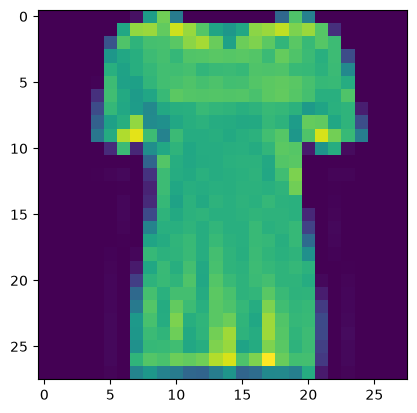

In [3]:
#x_train[10]
plt.imshow(x_train[10])

In [4]:
# Label mapper

idx_to_label = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [5]:
idx_to_label[y_train[10]]

'T-shirt/top'

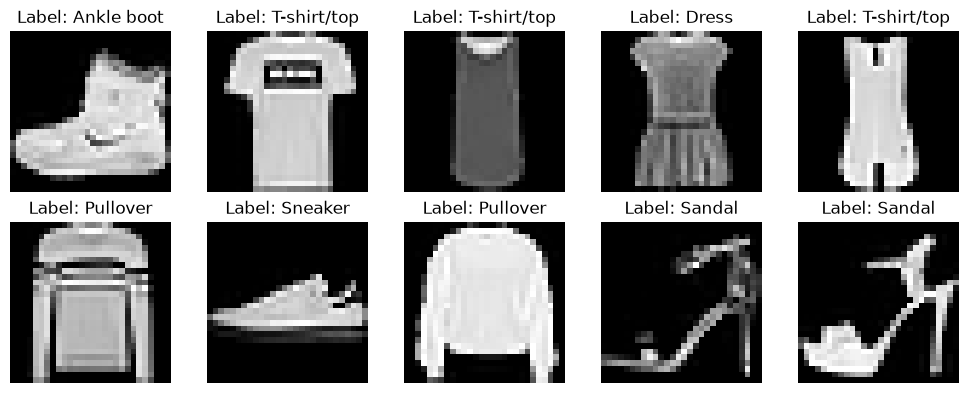

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {idx_to_label[y_train[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Data Preprocessing (Flatten + Normalize)

In [7]:
print(f"Train data shape before flattening: {x_train.shape}")
print(f"Test data shape before flatteing: {x_test.shape}")

x_train = x_train.reshape(60000, 28*28)
x_test = x_test.reshape(10000, 28*28)

print(f"Train data shape after flattening: {x_train.shape}")
print(f"Test data shape after flatteing: {x_test.shape}")

Train data shape before flattening: (60000, 28, 28)
Test data shape before flatteing: (10000, 28, 28)
Train data shape after flattening: (60000, 784)
Test data shape after flatteing: (10000, 784)


In [8]:
print(f"Max pixel value before Normalization: {x_train.max()}")
print(f"Min pixel value before Normalization: {x_train.min()}")

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f"Max pixel value after Normalization: {x_train.max()}")
print(f"Min pixel value after Normalization: {x_train.min()}")

Max pixel value before Normalization: 255
Min pixel value before Normalization: 0
Max pixel value after Normalization: 1.0
Min pixel value after Normalization: 0.0


# Build ANN Model

In [9]:
model = keras.Sequential([

    layers.Input(shape=(784,)),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(0.3),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.01),
    layers.Dropout(0.2),

    layers.Dense(10),
    layers.Softmax()

])

d:\Ostad\Ostad(Deep Learning)\Deep Learning Practice\env\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


# Compile Model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,         
    restore_best_weights=True 
)

# Train Model

In [12]:
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7855 - loss: 0.6207 - val_accuracy: 0.8524 - val_loss: 0.4100
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8401 - loss: 0.4478 - val_accuracy: 0.8628 - val_loss: 0.3816
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8515 - loss: 0.4100 - val_accuracy: 0.8662 - val_loss: 0.3684
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8592 - loss: 0.3855 - val_accuracy: 0.8682 - val_loss: 0.3598
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8664 - loss: 0.3706 - val_accuracy: 0.8711 - val_loss: 0.3489
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8716 - loss: 0.3544 - val_accuracy: 0.8770 - val_loss: 0.3469
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8750 - loss: 0.3414 - val_accuracy: 0.8758 - val_loss: 0.3432
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8790 - loss: 0.3303 - val_accuracy: 0.

# Training Visualization

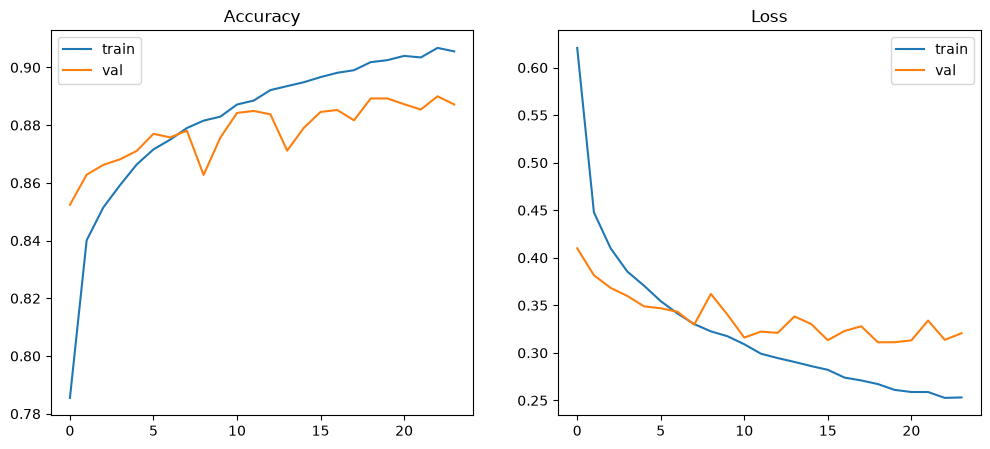

In [13]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

# Predictions Visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


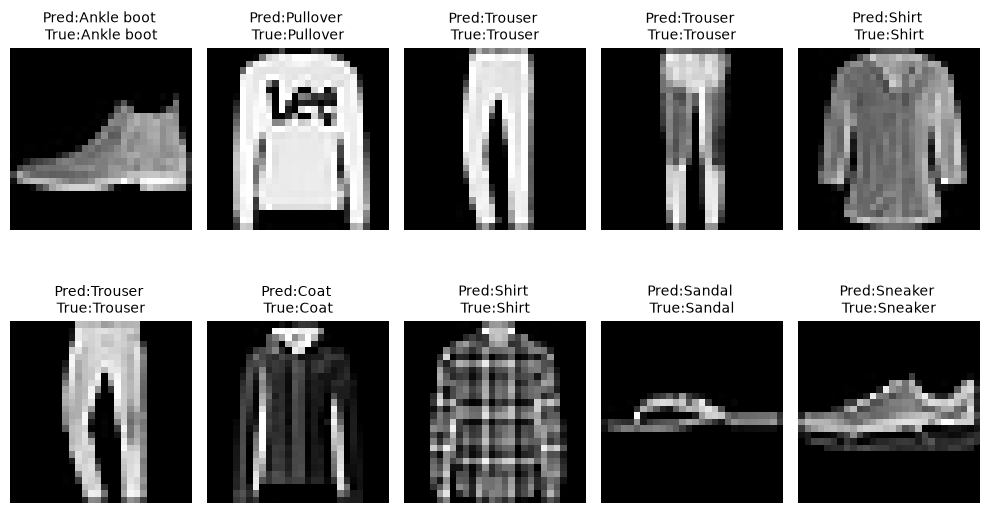

In [14]:
predictions = model.predict(x_test)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"Pred:{idx_to_label[pred_label]} \nTrue:{idx_to_label[true_label]}",
              fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# Evaluate Model

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8827 - loss: 0.3334
Test Accuracy: 0.8827000260353088


In [16]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)


print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.82      0.78      0.79      1000
           3       0.91      0.86      0.89      1000
           4       0.78      0.84      0.81      1000
           5       0.97      0.96      0.97      1000
           6       0.67      0.70      0.69      1000
           7       0.93      0.95      0.94      1000
           8       0.98      0.96      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Error Analysis

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step


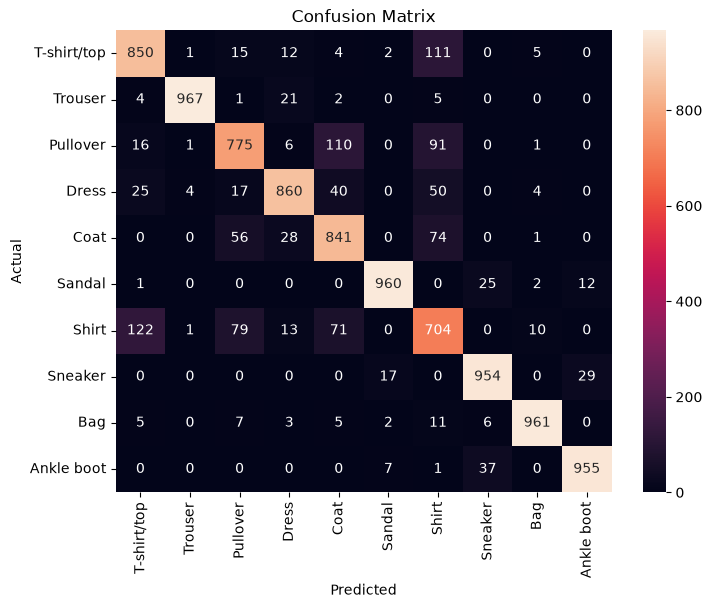

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=idx_to_label.values(),
    yticklabels=idx_to_label.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step
Total errors: 1173


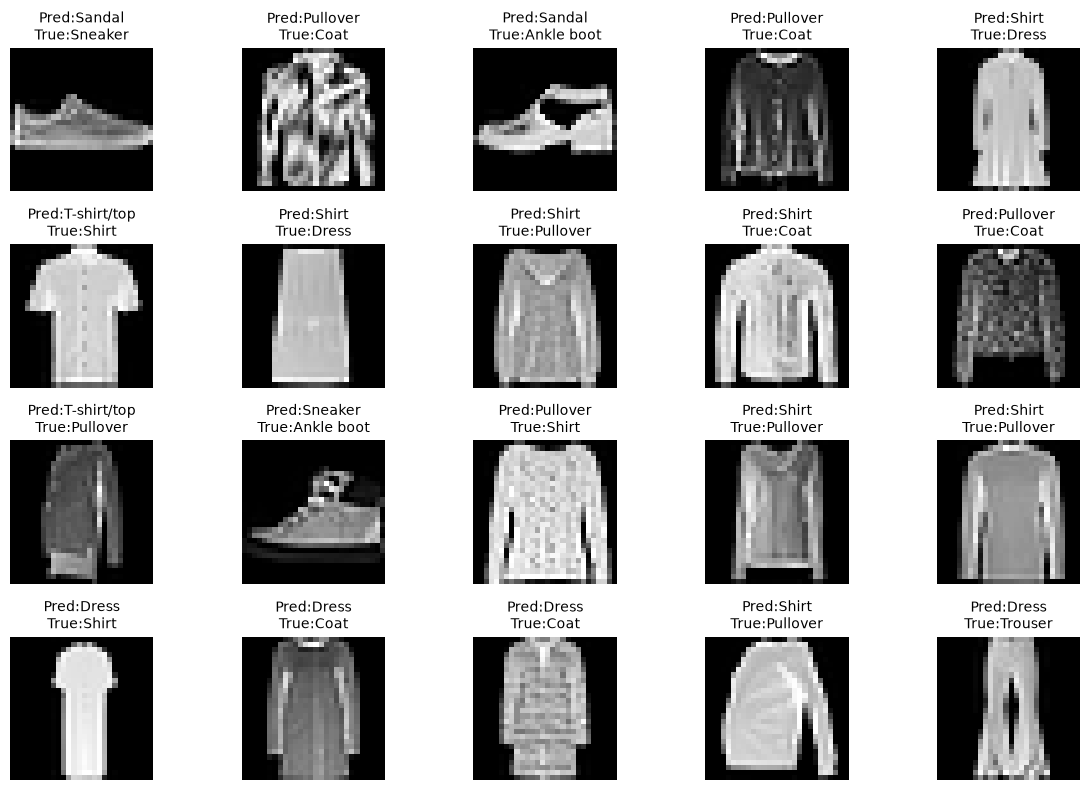

In [18]:
# Get predictions
predictions = model.predict(x_test)

# Convert probabilities to labels
pred_labels = np.argmax(predictions, axis=1)


# Find wrong predictions
errors = np.where(pred_labels != y_test)[0]


print("Total errors:", len(errors))


# Visualize wrong predictions
plt.figure(figsize=(12, 8))

for i, idx in enumerate(errors[:20]):   # show first 20 mistakes

    plt.subplot(4, 5, i+1)

    plt.imshow(
        x_test[idx].reshape(28,28),
        cmap='gray'
    )

    pred_label = pred_labels[idx]
    true_label = y_test[idx]

    plt.title(
        f"Pred:{idx_to_label[pred_label]}\nTrue:{idx_to_label[true_label]}",
        fontsize=10
    )

    plt.axis('off')


plt.tight_layout()
plt.show()

# Saving the Model

In [19]:
model_name = "ann_fashion_mnist_with_batchnorm_&_DropOut.h5"

model.save(model_name)

In [20]:
loaded_model = tf.keras.models.load_model(model_name)
print("Model loaded successfully!")

Model loaded successfully!
